In [1]:
import yfinance as yf
import pandas as pd
import numpy as np


In [ ]:
# 1. Poder obtener los valores del dolar
dolar = 'COP=X'

df_precios = yf.download(dolar, start='2021-01-01', end='2026-08-01')["Close"]

# 2. Limpiar que no tenga valores faltantes
df_precios = df_precios.ffill().dropna()
df_precios

[*********************100%***********************]  1 of 1 completed


Ticker,COP=X
Date,
2021-01-01,3420.250000
2021-01-04,3420.250000
2021-01-05,3447.750000
2021-01-06,3442.250000
2021-01-07,3412.800049
...,...
2026-07-27,3216.909912
2026-07-28,3204.340088
2026-07-29,3211.110107


In [20]:
from statsmodels.tsa.stattools import adfuller, acf, pacf
# Calcular retornos logaritmicos
df_retornos = np.log(df_precios/df_precios.shift(1)).dropna()

# ADF
resultado_adf = adfuller(df_retornos)

print("RESULTADOS")
print(f"Estadistico ADF: {resultado_adf[0]:.4f}")
print(f"p-value: {resultado_adf[1]:.4e}")


RESULTADOS
Estadistico ADF: -8.9673
p-value: 7.9271e-15


# RESULTADOS
Aca podemos ver que con los retornos logaritmicos, vemos que el p-value es menor a 0.05 por lo cual rechazariamos la hipotesis nula de que la serie tiene una raiz unitaria y estariamos ante una serie estacionaria

Buscamos si es ruido blanco la serie

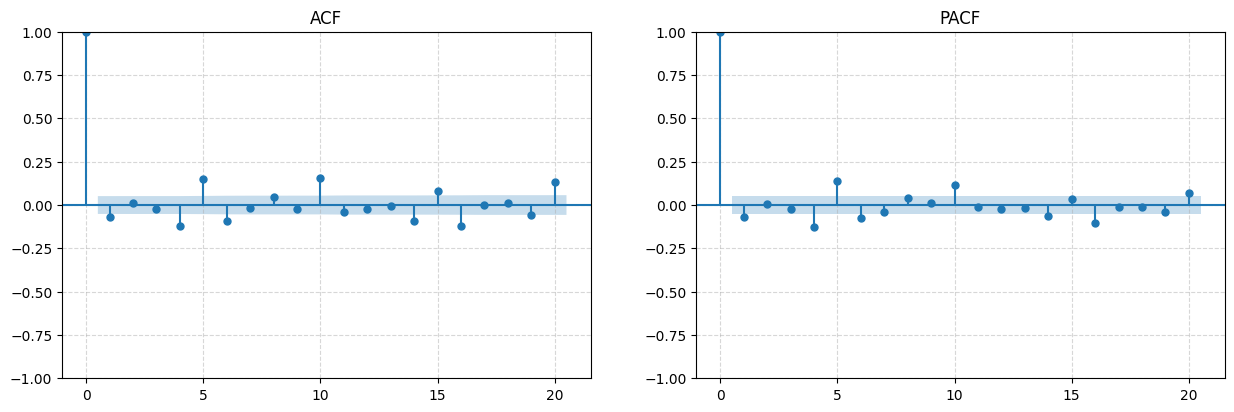

In [16]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))


plot_acf(df_retornos, lags=20, title="ACF", ax=axes[0])
axes[0].grid(True, linestyle='--', alpha=0.5)
plot_pacf(df_retornos, lags=20, title="PACF", ax=axes[1])
axes[1].grid(True, linestyle='--', alpha=0.5)

In [18]:
from statsmodels.stats.diagnostic import acorr_ljungbox
resultado = acorr_ljungbox(df_retornos, lags=[10], return_df=True)

print(resultado)

       lb_stat     lb_pvalue
10  113.028211  1.305954e-19


In [38]:
df_retornos.index = pd.to_datetime(df_retornos.index)
df_retornos["dia"] = df_retornos.index.dayofweek
df_retornos["name_day"] = df_retornos.index.day_name()
df_retornos.groupby("name_day").mean()

Ticker,COP=X,dia
name_day,,
Friday,0.000104,4.0
Monday,-0.004289,0.0
Thursday,-0.001002,3.0
Tuesday,0.004101,1.0
Wednesday,0.000753,2.0


Se observó un posible efecto de día de la semana en los retornos (lunes negativo, martes positivo), consistente con literatura sobre anomalías de calendario en mercados cambiarios.